In [77]:
"""
Research Question 1:
What patterns of asymmetric price transmission can be observed
between dairy producer prices and retail butter prices in Germany?

Dataset variables:
- month: monthly time index
- butter_cpi: consumer price index for butter
- dairy_ppi: producer price index for dairy products
- dairy_cpi: consumer price index for dairy products

"""

import json
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns


def eurostat_json_to_df(data): # convert json to tabular
    """
    Convert a Eurostat JSON dataset into a clean monthly DataFrame.

    Parameters
    ----------
    data : dict
        Eurostat JSON data.

    Returns
    -------
    pandas.DataFrame
        DataFrame with columns month and value.
    """

    # Extract the monthly time index from the Eurostat structure.
    time_index = data["dimension"]["time"]["category"]["index"]
    time_df = pd.DataFrame(list(time_index.items()), columns=["month", "pos"])

    # Extract the values and align them with the time positions.
    values = data["value"]
    value_df = pd.DataFrame(list(values.items()), columns=["pos", "value"])
    value_df["pos"] = value_df["pos"].astype(int)

    # Merge time positions with observed values.
    df = pd.merge(time_df, value_df, on="pos")
    df = df.drop(columns=["pos"])

    return df

# Load raw Eurostat JSON files for butter CPI, dairy PPI, and dairy CPI.
with open("eurostat_butter_cpi.json", "r", encoding="utf-8") as file:
    data_butter = json.load(file)

with open("eurostat_ppi_dairy.json", "r", encoding="utf-8") as file:
    data_ppi = json.load(file)

with open("eurostat_cpi_dairy.json", "r", encoding="utf-8") as file:
    data_cpi = json.load(file)

# Convert the three raw JSON objects into tabular DataFrames.
butter_df = eurostat_json_to_df(data_butter) 
ppi_df = eurostat_json_to_df(data_ppi)
cpi_df = eurostat_json_to_df(data_cpi)


print("Butter CPI")
print(butter_df.head())

print("\nDairy PPI")
print(ppi_df.head())

print("\nDairy CPI")
print(cpi_df.head())

Butter CPI
     month  value
0  2014-12   99.3
1  2015-01   99.3
2  2015-02   99.0
3  2015-03  105.7
4  2015-04  106.2

Dairy PPI
     month  value
0  2000-01   85.1
1  2000-02   85.0
2  2000-03   85.2
3  2000-04   85.1
4  2000-05   84.9

Dairy CPI
     month  value
0  1996-01   79.9
1  1996-02   79.9
2  1996-03   80.0
3  1996-04   80.1
4  1996-05   79.9


In [78]:
# Cleaning step 1: standardise date format, column names, and sorting.
# Convert month column to datetime
butter_df["month"] = pd.to_datetime(butter_df["month"])
ppi_df["month"] = pd.to_datetime(ppi_df["month"])
cpi_df["month"] = pd.to_datetime(cpi_df["month"])

# Rename value columns

butter_df = butter_df.rename(columns={"value": "butter_cpi"})
ppi_df = ppi_df.rename(columns={"value": "dairy_ppi"})
cpi_df = cpi_df.rename(columns={"value": "dairy_cpi"})

# Sort by month
butter_df = butter_df.sort_values("month").reset_index(drop=True)
ppi_df = ppi_df.sort_values("month").reset_index(drop=True)
cpi_df = cpi_df.sort_values("month").reset_index(drop=True)

#  cleaned tables
print("Cleaned Butter CPI")
print(butter_df.head())

print("\nCleaned Dairy PPI")
print(ppi_df.head())

print("\nCleaned Dairy CPI")
print(cpi_df.head())

Cleaned Butter CPI
       month  butter_cpi
0 2014-12-01        99.3
1 2015-01-01        99.3
2 2015-02-01        99.0
3 2015-03-01       105.7
4 2015-04-01       106.2

Cleaned Dairy PPI
       month  dairy_ppi
0 2000-01-01       85.1
1 2000-02-01       85.0
2 2000-03-01       85.2
3 2000-04-01       85.1
4 2000-05-01       84.9

Cleaned Dairy CPI
       month  dairy_cpi
0 1996-01-01       79.9
1 1996-02-01       79.9
2 1996-03-01       80.0
3 1996-04-01       80.1
4 1996-05-01       79.9


In [79]:
# Cleaning step 2: filter the inflation period and remove invalid rows.
# Store row counts before filtering and cleaning.
butter_before = len(butter_df)
ppi_before = len(ppi_df)
cpi_before = len(cpi_df)

# Keep only the analysis period from January 2020 to December 2023.
butter_df = butter_df[(butter_df["month"] >= "2020-01-01") & (butter_df["month"] <= "2023-12-01")]
ppi_df = ppi_df[(ppi_df["month"] >= "2020-01-01") & (ppi_df["month"] <= "2023-12-01")]
cpi_df = cpi_df[(cpi_df["month"] >= "2020-01-01") & (cpi_df["month"] <= "2023-12-01")]

# Store row counts after time filtering.
butter_afterTime = len(butter_df)
ppi_afterTime = len(ppi_df)
cpi_afterTime = len(cpi_df)

# Remove missing values.
butter_df = butter_df.dropna()
ppi_df = ppi_df.dropna()
cpi_df = cpi_df.dropna()

# Remove duplicate rows.
butter_df = butter_df.drop_duplicates()
ppi_df = ppi_df.drop_duplicates()
cpi_df = cpi_df.drop_duplicates()

# Sort rows and reset the index.
butter_df = butter_df.sort_values("month").reset_index(drop=True)
ppi_df = ppi_df.sort_values("month").reset_index(drop=True)
cpi_df = cpi_df.sort_values("month").reset_index(drop=True)

# Store final row counts after cleaning.
butter_after_time = len(butter_df)
ppi_after_time = len(ppi_df)
cpi_after_time = len(cpi_df)

# Print row counts before and after cleaning.
print(butter_before, butter_after_time, butter_after)
print(ppi_before, ppi_after_time, ppi_after)
print(cpi_before, cpi_after_time, cpi_after)

133 48 48
288 48 48
360 48 48


In [80]:
# Merge the three monthly series into one analysis table.
merged_df = butter_df.merge(ppi_df, on="month")
merged_df = merged_df.merge(cpi_df, on="month")

print(merged_df.head())


       month  butter_cpi  dairy_ppi  dairy_cpi
0 2020-01-01       144.9      111.4      110.9
1 2020-02-01       143.3      111.9      110.9
2 2020-03-01       142.7      111.4      111.1
3 2020-04-01       142.5      109.6      111.6
4 2020-05-01       142.3      108.1      113.2


In [81]:
# Compute month-to-month changes in producer and butter consumer prices.
merged_df["ppi_change"] = merged_df["dairy_ppi"].diff()
merged_df["butter_change"] = merged_df["butter_cpi"].diff()


print(merged_df.head())

       month  butter_cpi  dairy_ppi  dairy_cpi  ppi_change  butter_change
0 2020-01-01       144.9      111.4      110.9         NaN            NaN
1 2020-02-01       143.3      111.9      110.9         0.5           -1.6
2 2020-03-01       142.7      111.4      111.1        -0.5           -0.6
3 2020-04-01       142.5      109.6      111.6        -1.8           -0.2
4 2020-05-01       142.3      108.1      113.2        -1.5           -0.2


In [82]:
# Split the dataset into months with increasing and decreasing producer prices.
ppi_increase = merged_df[merged_df["ppi_change"] > 0]
ppi_decrease = merged_df[merged_df["ppi_change"] < 0]

print(len(ppi_increase))
print(len(ppi_decrease))

31
16


In [83]:
# Calculate the average butter price reaction for producer price increases and decreases.
butter_reaction_increase = ppi_increase["butter_change"].mean() 
butter_reaction_decrease = ppi_decrease["butter_change"].mean() 

print(butter_reaction_increase, "Average reaction when producer prices increase")
print(butter_reaction_decrease, "Average reaction when producer prices decrease")


2.629032258064516 Average reaction when producer prices increase
-3.7125000000000004 Average reaction when producer prices decrease


In [84]:
# Add a categorical label for the direction of producer price change.
merged_df["ppi_direction"] = merged_df["ppi_change"].apply(
    lambda x: "increase" if x > 0 else "decrease" if x < 0 else None
)

print(merged_df.head())

       month  butter_cpi  dairy_ppi  dairy_cpi  ppi_change  butter_change  \
0 2020-01-01       144.9      111.4      110.9         NaN            NaN   
1 2020-02-01       143.3      111.9      110.9         0.5           -1.6   
2 2020-03-01       142.7      111.4      111.1        -0.5           -0.6   
3 2020-04-01       142.5      109.6      111.6        -1.8           -0.2   
4 2020-05-01       142.3      108.1      113.2        -1.5           -0.2   

  ppi_direction  
0          None  
1      increase  
2      decrease  
3      decrease  
4      decrease  


In [85]:
# Interactive notebook figure: monthly price transmission scatter plot.
fig = px.scatter(
    merged_df,
    x="ppi_change",
    y="butter_change",
    color="ppi_direction",
    title="Quadrant View of Price Transmission between Producer and Retail Prices",
    labels={
        "ppi_change": "Change in Dairy Producer Price Index",
        "butter_change": "Change in Butter Consumer Price Index"
    }
)

fig.add_vline(x=0, line_dash="dash", line_color="gray")
fig.add_hline(y=0, line_dash="dash", line_color="gray")

fig.show()

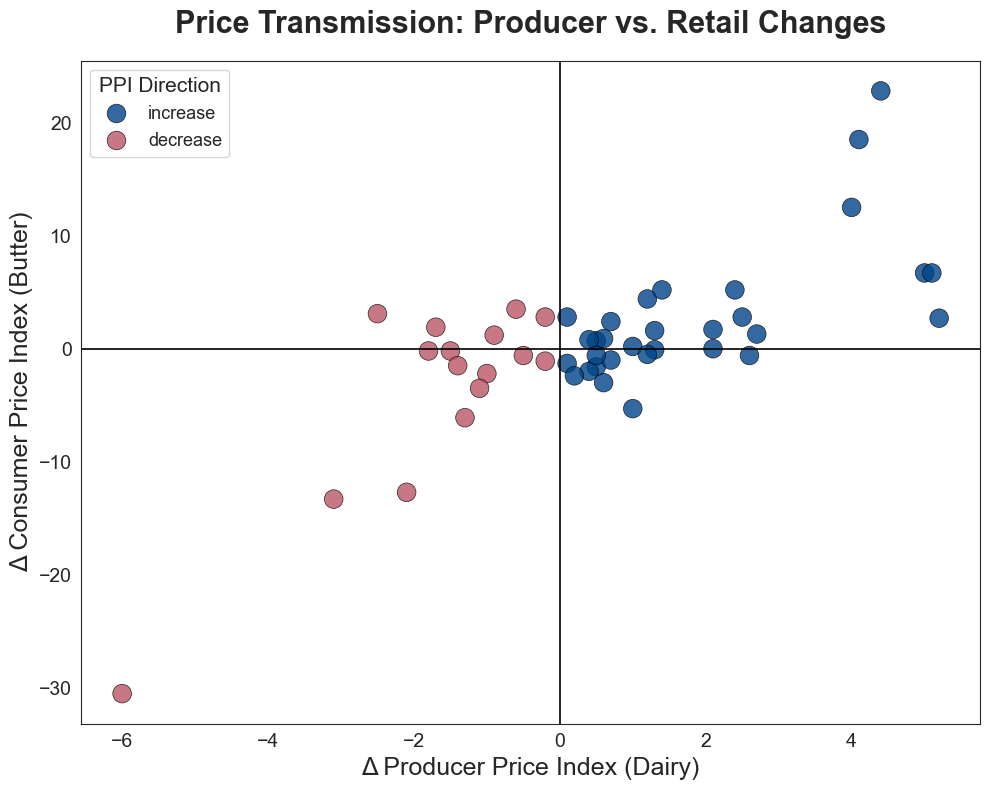

In [86]:
# Static poster figure: high-resolution scatter plot for poster use.


# Define consistent colors for increasing and decreasing producer prices.
colors = {"increase": "#004488", "decrease": "#BB5566"}

plt.figure(figsize=(10, 8))
sns.set_style("white")  # Clean white background for poster output.

# Create the scatter plot.
sns.scatterplot(
    data=merged_df,
    x="ppi_change",
    y="butter_change",
    hue="ppi_direction",
    palette=colors,
    s=180,  # Larger markers for better poster readability.
    alpha=0.8, 
    edgecolor="black",
    linewidth=0.5
)

# Add horizontal and vertical reference lines for the four quadrants.
plt.axhline(0, color='black', linewidth=1.2, linestyle='-')
plt.axvline(0, color='black', linewidth=1.2, linestyle='-')

# Increase text size for poster readability.
plt.title("Price Transmission: Producer vs. Retail Changes", fontsize=22, fontweight='bold', pad=20)
plt.xlabel("Δ Producer Price Index (Dairy)", fontsize=18)
plt.ylabel("Δ Consumer Price Index (Butter)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Format the legend.
plt.legend(title="PPI Direction", title_fontsize='15', fontsize='13', loc='upper left')

# Export the figure in high resolution for print use.
plt.tight_layout()
plt.savefig('RQ1_Quadrant_Scatter_HD.png', dpi=300, bbox_inches='tight')
plt.show()



In [88]:
# Create a small summary table for the average butter price reaction.
reaction_df = pd.DataFrame({
    "producer_price_change": ["increase", "decrease"],
    "butter_price_reaction": [
        butter_reaction_increase,
        butter_reaction_decrease
    ]
})
# Interactive notebook figure: compare average reactions across price directions.
fig = px.bar(
    reaction_df,
    x="producer_price_change",
    y="butter_price_reaction",
    title="Average Butter Price Reaction to Producer Price Changes",
    labels={
        "producer_price_change": "Producer Price Movement",
        "butter_price_reaction": "Average Change in Butter Price"
    }
)

fig.show()

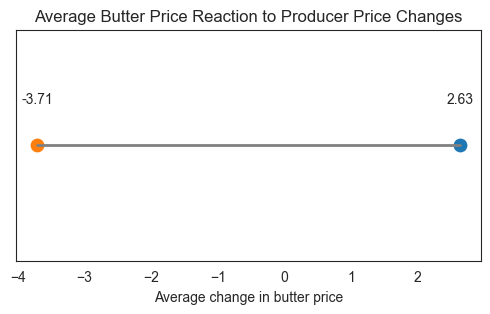

In [90]:
# Static notebook figure: simple dumbbell-style comparison.

labels = ["Producer price increase", "Producer price decrease"]
values = [butter_reaction_increase, butter_reaction_decrease]

plt.figure(figsize=(6,3))

# Draw the connecting line.
plt.plot(values, [1,1], color="gray", linewidth=2)

# Draw the two comparison points.
plt.scatter(values[0], 1, s=80)
plt.scatter(values[1], 1, s=80)

# Display the values above the points.
plt.text(values[0], 1.02, round(values[0],2), ha="center")
plt.text(values[1], 1.02, round(values[1],2), ha="center")

plt.yticks([])
plt.xlabel("Average change in butter price")
plt.title("Average Butter Price Reaction to Producer Price Changes")

plt.show()